# Fraud Detection


It is a bank fraud detection using machine learning.<br>Things we will cover is Problem and data Understanding. Data Cleaning and features. Model training and last optimization.

<b> Required Libraries

In [83]:
import os
import warnings
warnings.filterwarnings('ignore') # simply ignore unnecessary warning make output clean and friendly
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

import joblib

Explaination to the libraries we imported

RobustScaler removes the median and scales the data according to the quantile range.<br>
Label Encoder is used to convert categorical text data into numeric values

<b> Importing DataSet

In [84]:
df = pd.read_csv('Fraud.csv')

In [85]:
df.sample(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1953293,178,CASH_OUT,283029.69,C1697752099,126.0,0.00,C1319168934,831081.26,1114110.95,0,0
2803375,225,CASH_IN,280976.61,C1431615141,99038.0,380014.61,C1210315704,5173995.15,4893018.55,0,0
931885,43,PAYMENT,2847.47,C89740920,0.0,0.00,M1558543579,0.00,0.00,0,0
3436821,256,CASH_OUT,79282.49,C624675564,0.0,0.00,C1969195471,29252076.04,29331358.53,0,0
6313760,687,CASH_IN,490231.56,C1064873647,32469.0,522700.56,C1772724554,87146.19,0.00,0,0


<b> Explaining Dataset

1. step - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).
<br><br>
2. type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.
<br><br>
3. amount
<br><br>
4. nameOrig - customer who started the transaction
<br><br>
5. oldbalanceOrg - balance before the transaction
<br><br>
6. newbalanceOrig - balance after the transaction
<br><br>
7. nameDest - destination, customer who will receive the amoount
<br><br>
8. oldbalanceDest - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).
<br><br>
9. newbalanceDest - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).
<br><br>
10. isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system. 1 means its fraud , zero means the transaction was legitmate
<br><br>
11. isFlaggedFraud - The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

In [86]:
# Quick EDA
print("Shape " , df.shape)
print("DataType", df.dtypes)
print("Null values in the data", df.isnull().sum())
print(df['isFraud'].value_counts())
print('Fraud Ratio',df['isFraud'].mean())

Shape  (6362620, 11)
DataType step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object
Null values in the data step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud Ratio 0.001290820448180152


Text(0.5, 1.0, 'Fraud rate by transaction amount bucket')

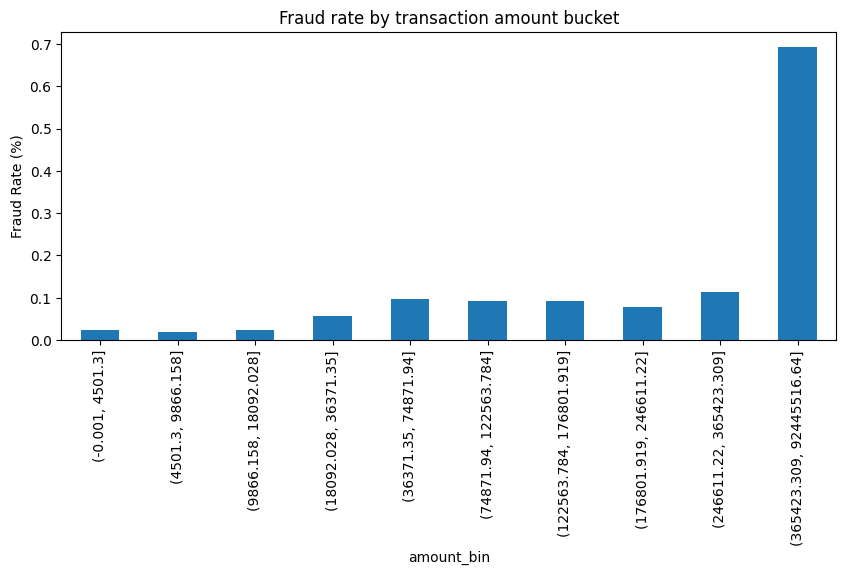

In [87]:
# Fraud Rate By Amount bucket
# We will make different bucket of almost same range of amount
df['amount_bin'] = pd.qcut(df['amount'], q=10,duplicates='drop')

fraud_rate = df.groupby('amount_bin')['isFraud'].mean()
fraud_rate=fraud_rate*100

plt.figure(figsize=(10,4))
fraud_rate.plot(kind='bar')
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud rate by transaction amount bucket")

From the given graph we can say that higher value transaction should check strictly as there is more chance of fraud in these type of transaction.

In [88]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,amount_bin
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,"(4501.3, 9866.158]"
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,"(-0.001, 4501.3]"
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,"(-0.001, 4501.3]"
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,"(-0.001, 4501.3]"
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,"(9866.158, 18092.028]"


In [89]:
print(df[df['nameDest'].str.startswith('M')].head())

   step     type    amount  ... isFraud  isFlaggedFraud             amount_bin
0     1  PAYMENT   9839.64  ...       0               0     (4501.3, 9866.158]
1     1  PAYMENT   1864.28  ...       0               0       (-0.001, 4501.3]
4     1  PAYMENT  11668.14  ...       0               0  (9866.158, 18092.028]
5     1  PAYMENT   7817.71  ...       0               0     (4501.3, 9866.158]
6     1  PAYMENT   7107.77  ...       0               0     (4501.3, 9866.158]

[5 rows x 12 columns]


In [90]:
df[df['isFraud'] == 1]['nameDest'].str.startswith('M').value_counts()

nameDest
False    8213
Name: count, dtype: int64

There is no missing values. And no imputation will be performed as zero represent valid mercchant behaviour, not missing data.

We can also see that there is no fraud done by merchant. So when there is transaction between merchant there will be no fraud.

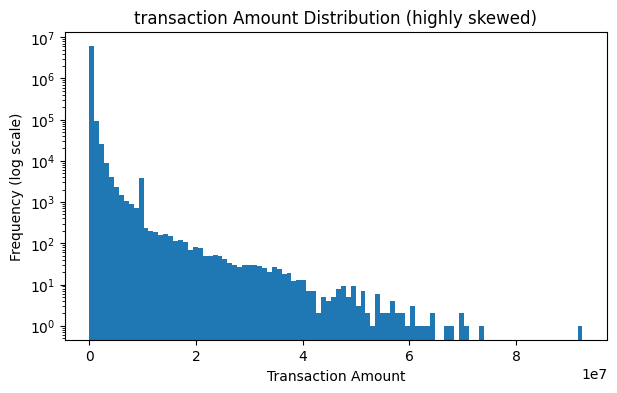

In [91]:
# outlier handling
df['amount'].describe()

# visualize skewness (as we ca see very few transaction are in small scale and many transaction are large amount)

plt.figure(figsize=(7,4))
plt.hist(df['amount'],bins=100)
plt.yscale('log')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency (log scale)')
plt.title('transaction Amount Distribution (highly skewed)')
plt.show()


In [92]:
# Log transform to reduce skewenedd
df['log_amount'] = np.log1p(df['amount'])

# flag transaction above 99th percentile
p99 = df['amount'].quantile(0.99)
df['is_high_amount'] = (df['amount']>p99).astype(int)

df['is_high_amount'].value_counts()

is_high_amount
0    6298993
1      63627
Name: count, dtype: int64

In the above code we create the column high amount. We choose a percentile if the value is greater than 99% of other values mark as 1. That transaction will be suspicious signal that doesn't mean that is fraud thats just mean pay high attention to it.

In [93]:
# overview
total_trans = len(df)
fraud_trans = df['isFraud'].sum()
fraud_rate = fraud_trans/total_trans
fraud_pct = (df['isFraud'].sum()/total_trans)*100
flagged_pct = (df['isFlaggedFraud'].sum()/total_trans)*100

print(f"Total Transaction: {total_trans:,}")
print(f"Fraud transaction: {fraud_trans: ,}")
print(f"Overall Fraud rate: {fraud_rate:.4%}")
print(f"Fraudulent transaction (isFruad=1):{fraud_pct:.4f}%")
print(f"Flagged transaction (isFlaggedFraud=1): {flagged_pct:.4f}%")

Total Transaction: 6,362,620
Fraud transaction:  8,213
Overall Fraud rate: 0.1291%
Fraudulent transaction (isFruad=1):0.1291%
Flagged transaction (isFlaggedFraud=1): 0.0003%


0.13% are fraud and only 0.0003% fraud is flagged fraud indicating most of the fraud are go undetected.


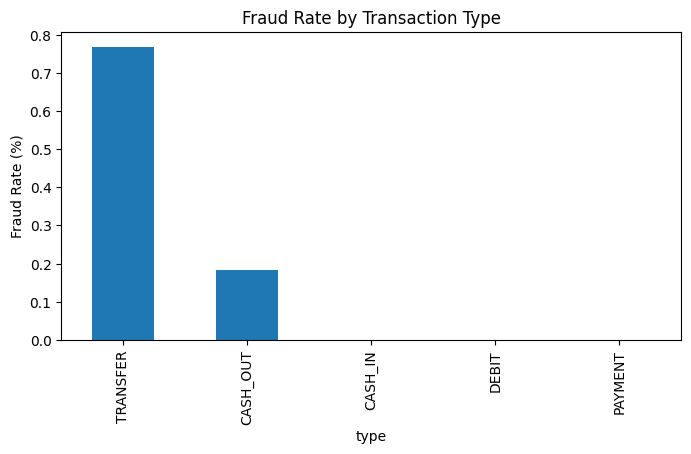

In [94]:
# fraud rate by transaction type
fraud_rate_by_type = df.groupby('type')['isFraud'].mean()*100
plt.figure(figsize=(8,4))
fraud_rate_by_type.sort_values(ascending=False).plot(kind='bar')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Transaction Type')
plt.show()

,hour,total_transaction,fraud_transactions,fraud_rate
0,0,71587,300,0.004191
1,1,27111,358,0.013205
2,2,9018,372,0.041251
3,3,2007,326,0.162431
4,4,1241,274,0.220790


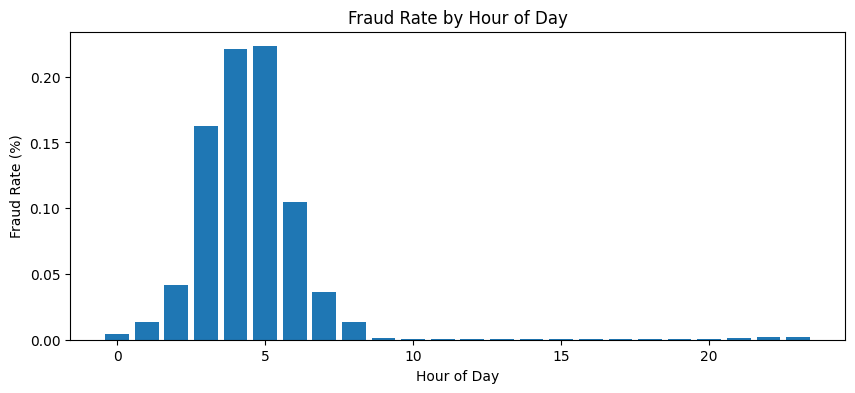

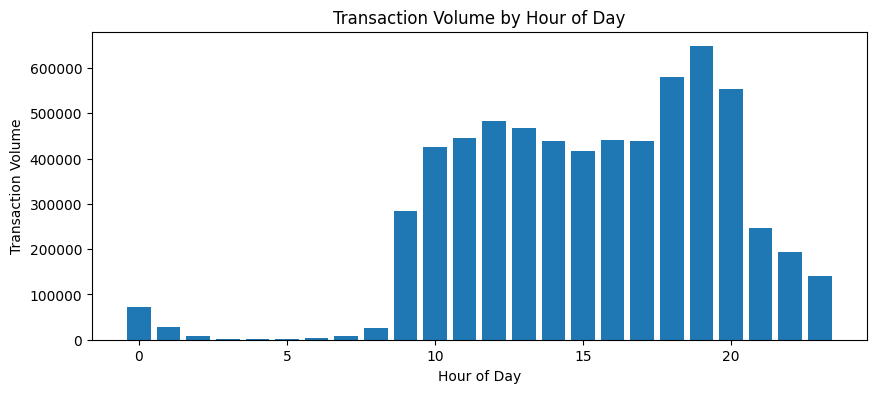

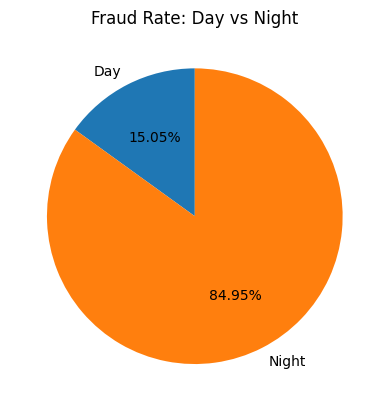

In [95]:
# Time based analysis
df['hour'] = (df['step']%24).astype(int)
# Aggregate hourly fraud rate
hourly_stats = (
    df.groupby('hour')
    .agg(
        total_transaction=('isFraud','count'),
        fraud_transactions = ('isFraud','sum'),
        fraud_rate = ('isFraud','mean')
    )
    .reset_index()
)
display(hourly_stats.head())

# fraud rate by hour
plt.figure(figsize=(10,4))
plt.bar(hourly_stats['hour'], hourly_stats['fraud_rate'])
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Hour of Day')
plt.show()

# transaction volume by hour
plt.figure(figsize=(10,4))
plt.bar(hourly_stats['hour'], hourly_stats['total_transaction'])
plt.xlabel('Hour of Day')
plt.ylabel('Transaction Volume')
plt.title('Transaction Volume by Hour of Day')
plt.show()

# day vs night fraud rate
df['is_night'] = df['hour'].isin([0,1,2,3,4,5,6,21,22,23]).astype(int)
day_night_fraud = (
    df.groupby('is_night')['isFraud']
      .mean()  # average fraud rate
      .rename({0: 'Day', 1: 'Night'})
)

day_night_fraud.plot(
    kind='pie',
    autopct='%1.2f%%',      
    startangle=90,
    legend=False
)

plt.ylabel('') 
plt.title('Fraud Rate: Day vs Night')
plt.show()

In [96]:
# Correlation analysis

numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()


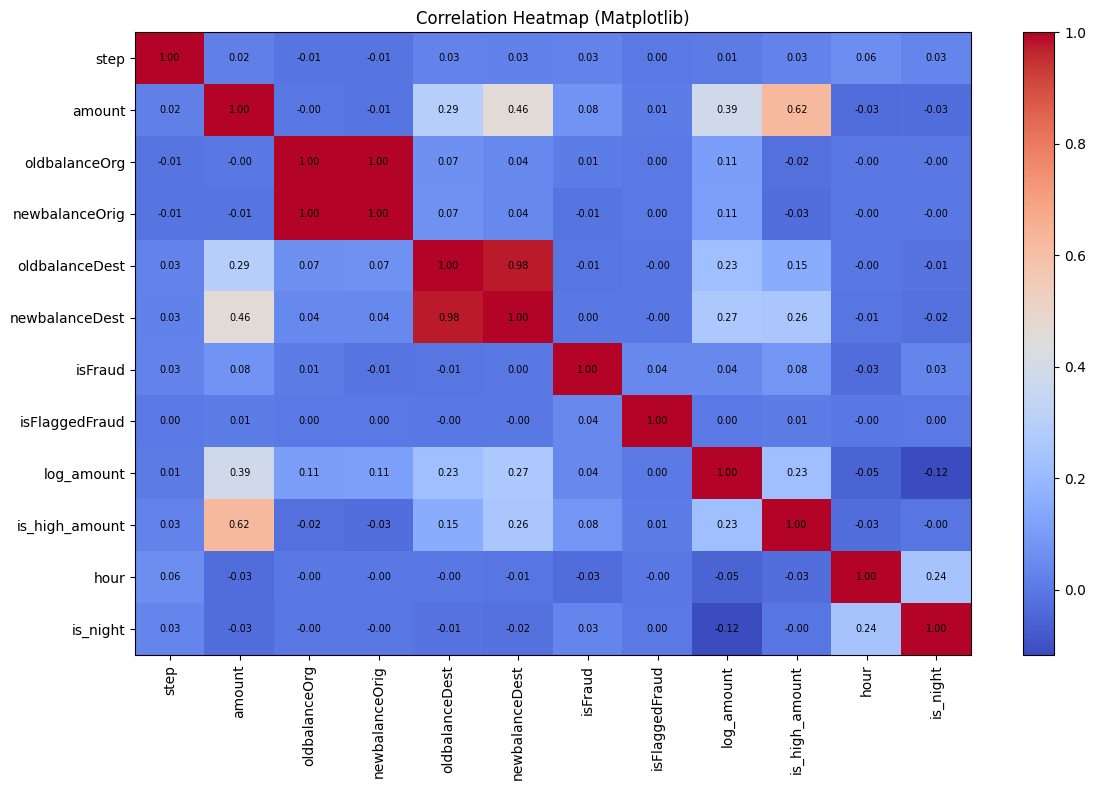

In [97]:
corr = correlation_matrix.values  # convert to numpy array

plt.figure(figsize=(12,8))
plt.imshow(corr, cmap='coolwarm', aspect='auto')

# add color bar
plt.colorbar()

# add axis labels
plt.xticks(ticks=np.arange(len(correlation_matrix.columns)),
           labels=correlation_matrix.columns, rotation=90)

plt.yticks(ticks=np.arange(len(correlation_matrix.columns)),
           labels=correlation_matrix.columns)

# add values inside cells
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j, i, f"{corr[i, j]:.2f}",
                 ha='center', va='center', fontsize=7)

plt.title("Correlation Heatmap (Matplotlib)")
plt.tight_layout()
plt.show()

The ccorrelation matrix reveals sever multicollinearity between pre and post transaction balances, indicating redundancy. These redundant variables need to be removed ad include a single column. In simple term variables are similar they are same thing. Keeping both add no new information.

<b> Feature Engineering & DATA CLEANING

In [98]:
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['oldbalanceDest'] - df['newbalanceDest']

df = df.drop(columns=['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest'])
df.head()

,step,type,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,amount_bin,log_amount,is_high_amount,hour,is_night,balance_diff_orig,balance_diff_dest
0,1,PAYMENT,9839.64,C1231006815,M1979787155,0,0,"(4501.3, 9866.158]",9.194276,0,1,1,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,M2044282225,0,0,"(-0.001, 4501.3]",7.531166,0,1,1,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,C553264065,1,0,"(-0.001, 4501.3]",5.204007,0,1,1,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,C38997010,1,0,"(-0.001, 4501.3]",5.204007,0,1,1,181.00,21182.0
4,1,PAYMENT,11668.14,C2048537720,M1230701703,0,0,"(9866.158, 18092.028]",9.364703,0,1,1,11668.14,0.0


In [99]:
df.drop(columns=['amount_bin'], inplace=True)

In [100]:
df.fillna(0, inplace=True)

le = LabelEncoder()
df['type_enc'] = le.fit_transform(df['type'])

df.drop(columns=['type','nameOrig','nameDest'],axis=1, inplace=True)

In [101]:
df.head()

,step,amount,isFraud,isFlaggedFraud,log_amount,is_high_amount,hour,is_night,balance_diff_orig,balance_diff_dest,type_enc
0,1,9839.64,0,0,9.194276,0,1,1,9839.64,0.0,3
1,1,1864.28,0,0,7.531166,0,1,1,1864.28,0.0,3
2,1,181.00,1,0,5.204007,0,1,1,181.00,0.0,4
3,1,181.00,1,0,5.204007,0,1,1,181.00,21182.0,1
4,1,11668.14,0,0,9.364703,0,1,1,11668.14,0.0,3


### Train Test Split

In [ ]:
X = df.drop(columns=['isFraud','isFlaggedFraud']) # remove isFlaggedFraud as it is highly correlated with isFraud and can cause data leakage
y= df['isFraud'].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

scaler = RobustScaler()
num_cols = X_train.select_dtypes(include=[np.number]).columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### Model Training & Evaluation

In [106]:
models ={}

# logistic regression
lr = LogisticRegression( random_state=42, max_iter=300,class_weight='balanced',solver='lbfgs',n_jobs=-1)
models['Logistic Regression'] = lr
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=50,max_depth=12,min_samples_leaf=100, random_state=42, class_weight='balanced', n_jobs=-1)
models['Random Forest'] = rf
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

#Xgboost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,subsample=0.8,colsample_bytree=0.8, random_state=42, scale_pos_weight=scale_pos_weight, tree_method='hist', eval_metric='logloss', n_jobs=-1)
xgb_clf.fit(X_train, y_train)
models['XGBoost'] = xgb_clf
y_pred_xgb = xgb_clf.predict(X_test)

In [109]:
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model': name,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score'],
        'roc_auc_score': roc_auc_score(y_test, model.predict_proba(X_test)[:,1]),
        'average_precision_score': average_precision_score(y_test, model.predict_proba(X_test)[:,1])
    })
    print(f"Classification Report for {name}:\n")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
results_df = pd.DataFrame(results).sort_values('average_precision_score', ascending=False)
print(results_df)

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.89      0.05      1643

    accuracy                           0.96   1272524
   macro avg       0.51      0.92      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524

[[1219139   51742]
 [    181    1462]]
Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.06      0.96      0.12      1643

    accuracy                           0.98   1272524
   macro avg       0.53      0.97      0.56   1272524
weighted avg       1.00      0.98      0.99   1272524

[[1247809   23072]
 [     61    1582]]
Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270881
           1       0.06      0.97

All the model receive high roc_auc_curve x, But XGBoost outperforms other we can also see this in confusion matrix

In [113]:
# tunining the decision threshold for best model (XGBoost)
from sklearn.metrics import precision_recall_curve

model = models['XGBoost']
y_scores = model.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)    


# find threshold with recall >=0.90 and best precision
candidates = [
    (t, p, r) for t, p, r in zip(thresholds, precision[:-1], recall[:-1])
    if r >= 0.90
]


best_threshold,best_precision, best_recall = max(candidates, key=lambda x: x[1])
print(f"Best Threshold: {best_threshold:.4f}, Precision: {best_precision:.4f}, Recall: {best_recall:.4f}")


Best Threshold: 0.9096, Precision: 0.3282, Recall: 0.9002


### Fine tunning the model

In [114]:
from xgboost import XGBClassifier
xgb_tuned = XGBClassifier(n_estimators=200,
                            max_depth=4,
                            learning_rate=0.05,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            min_child_weight=50,
                            scale_pos_weight=scale_pos_weight,
                            tree_method='hist',
                            eval_metric='logloss',
                            n_jobs=-1)

xgb_tuned.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [115]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=200,        # huge impact on precision
    min_samples_split=500,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",500
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",200
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [116]:
lr_tuned = LogisticRegression(
    max_iter=300,
    solver='lbfgs',
    class_weight='balanced',
    C=0.3                     # stronger regularization
)

lr_tuned.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.3
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [118]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate(model, X, y):
    scores = model.predict_proba(X)[:,1]
    return {
        "ROC-AUC": roc_auc_score(y, scores),
        "PR-AUC": average_precision_score(y, scores)
    }

print("XGB:", evaluate(xgb_tuned, X_test, y_test))
print("RF :", evaluate(rf_tuned, X_test, y_test))
print("LR :", evaluate(lr_tuned, X_test, y_test))
print(confusion_matrix(y_test, xgb_tuned.predict(X_test)))

XGB: {'ROC-AUC': 0.9982206050215333, 'PR-AUC': 0.8641571393316745}
RF : {'ROC-AUC': 0.9977487830012963, 'PR-AUC': 0.8404961047587548}
LR : {'ROC-AUC': 0.9783184117924976, 'PR-AUC': 0.5531122335565365}
[[1239119   31762]
 [     38    1605]]


### Saving the fine tuned model

In [129]:
models = {
    "LogisticRegression": lr_tuned,
    "RandomForest": rf_tuned,
    "XGBoost": xgb_tuned
}
best_model_name = max(models.keys(), key=lambda name: evaluate(models[name], X_test, y_test)['PR-AUC'])
best_model = models[best_model_name]


best_model_artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "threshold": best_threshold,     
    "features": X_train.columns.tolist()
}

joblib.dump(best_model_artifact, "best_fraud_model_tuned.pkl")

print(f" Saved best model: {best_model_name}")
print(f" Decision threshold: {best_threshold:.4f}")

 Saved best model: XGBoost
 Decision threshold: 0.9096


### Testing

In [133]:
# load saved model artifact
artifact = joblib.load('best_fraud_model_tuned.pkl')
model = artifact['model']
threshold = artifact['threshold']
features = artifact['features']

# predict on test data
y_scores = model.predict_proba(X_test[features])[:,1]
y_pred = (y_scores >= threshold).astype(int)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn , tp = cm.ravel()

# summary report
summary = pd.DataFrame({
    "count": [tp,fp,fn,tn],
}, index=[
    "correctly identified fraud (TP)",
    "missed fraud (FN)",
    "false alarm (FP)",
    "correctly identified non-fraud (TN)"
])
print(summary)

# quick fraud recall check
print(f"\n fraud recall: {tp/(tp+fn):.4f}")
print(f"fraud precision: {tp/(tp+fp):.4f}")

                                       count
correctly identified fraud (TP)         1473
missed fraud (FN)                       3566
false alarm (FP)                         170
correctly identified non-fraud (TN)  1267315

 fraud recall: 0.8965
fraud precision: 0.2923
